----------------------------------------
## CARACTERIZACION FORENSE DS3 Y DS4

**Narrativa forense Medicina Legal

In [1]:
#Validacion de los archivos forense y seforense en el forense analyzer
import sys
import logging
from pathlib import Path

%load_ext autoreload
%autoreload 2

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

FORENSE_CONFIG = str(PROJECT_ROOT / "config" / "forense_analyzer_config.json")

from forense_analyzer import ForenseAnalyzer

print("=" * 60)
print("VERIFICACIÓN — ForenseAnalyzer Steps 1 & 2")
print("=" * 60)

# Step 1: initialization
fa = ForenseAnalyzer(config_path=FORENSE_CONFIG)

# Step 2: load and validate both datasets
df4 = fa._load_and_validate("ds4")
df3 = fa._load_and_validate("ds3")

# Assertions
assert df4.shape == (15418, 21), f"DS4 shape inesperado: {df4.shape}"
assert df3.shape == (18661, 21), f"DS3 shape inesperado: {df3.shape}"
assert set(fa.ds4_config["columns_available"]).issubset(set(df4.columns))
assert set(fa.ds3_config["columns_available"]).issubset(set(df3.columns))

print()
print(f"forense | shape: {df4.shape} | cols: {sorted(df4.columns.tolist())}")
print(f"seforense | shape: {df3.shape} | cols: {sorted(df3.columns.tolist())}")
print()
print("✅ ForenseAnalyzer Steps 1 & 2 — PASS")

2026-06-17 11:04:27,035 - INFO - ForenseAnalyzer initialized | config: /Users/anaaguirre/Documents/Cicatrices_invisibles/config/forense_analyzer_config.json
2026-06-17 11:04:27,192 - INFO - Loaded ds4: 15418 rows × 21 columns
2026-06-17 11:04:27,195 - INFO - Loaded ds3: 18661 rows × 21 columns


VERIFICACIÓN — ForenseAnalyzer Steps 1 & 2

forense | shape: (15418, 21) | cols: ['agresor', 'anio_hecho', 'ciclo_vital', 'cod_municipio', 'departamento', 'dia_hecho', 'dias_incapacidad', 'dimension_agresor', 'dimension_discapacidad', 'dimension_escenario', 'dimension_etnia', 'discapacidad', 'escenario', 'etnia', 'factor', 'genero_victima', 'grupo_edad', 'hora_rango', 'mes_hecho', 'municipio', 'sexo_agresor']
seforense | shape: (18661, 21) | cols: ['agresor', 'anio_hecho', 'ciclo_vital', 'circunstancia', 'cod_municipio', 'departamento', 'dia_hecho', 'dimension_agresor', 'dimension_circunstancia', 'dimension_discapacidad', 'dimension_escenario', 'dimension_etnia', 'discapacidad', 'escenario', 'etnia', 'genero_victima', 'grupo_edad', 'hora_rango', 'mes_hecho', 'municipio', 'sexo_agresor']

✅ ForenseAnalyzer Steps 1 & 2 — PASS


In [2]:
#Creacion de tablas 
import sys, logging
from pathlib import Path
import pandas as pd

%load_ext autoreload
%autoreload 2

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from forense_analyzer import ForenseAnalyzer

config_path = str(PROJECT_ROOT / "config" / "forense_analyzer_config.json")
analyzer = ForenseAnalyzer(config_path=config_path)

# ── Generate all 12 tables ──────────────────────────────────────────────────
all_tables = analyzer.analyze_all()

print("\n" + "=" * 65)
print("TABLA                              SHAPE           COLUMNAS")
print("=" * 65)
for name, df in all_tables.items():
    print(f"{name:<35} {str(df.shape):<15} {df.columns.tolist()}")

# ── Assert 12 tables returned ──────────────────────────────────────────────
assert len(all_tables) == 12, f"Expected 12 tables, got {len(all_tables)}"
print(f"\n✅ analyze_all() returned {len(all_tables)} tables — OK")

# ── Assert parquet files on disk ───────────────────────────────────────────
DS4_DIR = PROJECT_ROOT / "data" / "agregados_forense"
DS3_DIR = PROJECT_ROOT / "data" / "agregados_seforense"

ds4_files = sorted(DS4_DIR.glob("*.parquet"))
ds3_files = sorted(DS3_DIR.glob("*.parquet"))

print(f"\nParquet files in {DS4_DIR.name}/  ({len(ds4_files)} files):")
for f in ds4_files:
    df = pd.read_parquet(f)
    print(f"  {f.name:<42} {df.shape}")

print(f"\nParquet files in {DS3_DIR.name}/ ({len(ds3_files)} files):")
for f in ds3_files:
    df = pd.read_parquet(f)
    print(f"  {f.name:<42} {df.shape}")

assert len(ds4_files) == 6, f"Expected 6 DS4 parquets, got {len(ds4_files)}"
assert len(ds3_files) == 6, f"Expected 6 DS3 parquets, got {len(ds3_files)}"
print("\n✅ 6 parquet files in each output directory — OK")

# ── Sanity checks ──────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("SANITY CHECKS")
print("=" * 65)

# 1. pct_femenino in [0, 100] for all tables that have it
for name in ["ds4_municipio_resumen", "ds4_interseccional",
             "ds3_municipio_resumen", "ds3_interseccional"]:
    df = all_tables[name]
    col = "pct_femenino"
    assert df[col].between(0, 100).all(), f"{name}.{col} out of [0,100]"
    print(f"✅ {name}.pct_femenino in [0,100]  (min={df[col].min():.1f}, max={df[col].max():.1f})")

# 2. pct_total sums to ~100 per department (floating-point tolerance)
for name in ["ds4_agresor", "ds4_escenario", "ds4_factor",
             "ds3_agresor", "ds3_escenario", "ds3_circunstancia"]:
    df = all_tables[name]
    dept_sums = df.groupby("departamento", observed=True)["pct_total"].sum()
    assert (dept_sums - 100).abs().lt(0.01).all(), \
        f"{name}: pct_total dept sums not ~100\n{dept_sums}"
    print(f"✅ {name}.pct_total sums to 100 per dept")

# 3. municipio_resumen: 1 row per municipality
for name in ["ds4_municipio_resumen", "ds3_municipio_resumen"]:
    df = all_tables[name]
    assert df["cod_municipio"].nunique() == len(df), \
        f"{name}: duplicate cod_municipio rows"
    print(f"✅ {name}: unique municipalities={len(df)}")

# 4. Mode columns are non-null strings
mode_checks = {
    "ds4_municipio_resumen": ["agresor_frecuente", "escenario_frecuente", "factor_mas_frecuente"],
    "ds3_municipio_resumen": ["agresor_frecuente", "circunstancia_frecuente"],
}
for name, cols in mode_checks.items():
    df = all_tables[name]
    for col in cols:
        null_count = df[col].isna().sum()
        assert null_count == 0, f"{name}.{col}: {null_count} nulls"
    print(f"✅ {name}: mode columns non-null ({cols})")

# 5. n_casos > 0 everywhere
for name, df in all_tables.items():
    if "n_casos" in df.columns:
        assert (df["n_casos"] > 0).all(), f"{name}: zero n_casos rows found"
print("✅ n_casos > 0 in all tables that have it")

# 6. Temporalidad: correct columns, no nulls in key fields
for name in ["ds4_temporalidad", "ds3_temporalidad"]:
    df = all_tables[name]
    assert set(df.columns) == {"departamento", "mes_hecho", "dia_hecho", "hora_rango", "n_casos"}, \
        f"{name}: unexpected columns {df.columns.tolist()}"
    assert df[["departamento", "mes_hecho", "dia_hecho", "hora_rango"]].notna().all().all(), \
        f"{name}: nulls in groupby keys"
    print(f"✅ {name}: schema OK, no nulls in groupby keys ({len(df)} combos)")

print("\n" + "=" * 65)
print("✅ ForenseAnalyzer Step 3 — analyze_all() PASS")
print("=" * 65)


2026-06-17 11:04:31,199 - INFO - ForenseAnalyzer initialized | config: /Users/anaaguirre/Documents/Cicatrices_invisibles/config/forense_analyzer_config.json


2026-06-17 11:04:31,204 - INFO - Loaded ds4: 15418 rows × 21 columns
2026-06-17 11:04:31,372 - INFO - Saved ds4_municipio_resumen: 161 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_forense/ds4_municipio_resumen.parquet
2026-06-17 11:04:31,380 - INFO - Saved ds4_agresor: 256 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_forense/ds4_agresor.parquet
2026-06-17 11:04:31,384 - INFO - Saved ds4_escenario: 31 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_forense/ds4_escenario.parquet
2026-06-17 11:04:31,389 - INFO - Saved ds4_factor: 34 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_forense/ds4_factor.parquet
2026-06-17 11:04:31,394 - INFO - Saved ds4_temporalidad: 2060 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_forense/ds4_temporalidad.parquet


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


2026-06-17 11:04:31,400 - INFO - Saved ds4_interseccional: 40 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_forense/ds4_interseccional.parquet
2026-06-17 11:04:31,400 - INFO - ForenseAnalyzer complete for ds4: 6 tables generated, 2582 total rows
2026-06-17 11:04:31,403 - INFO - Loaded ds3: 18661 rows × 21 columns
2026-06-17 11:04:31,554 - INFO - Saved ds3_municipio_resumen: 175 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_seforense/ds3_municipio_resumen.parquet
2026-06-17 11:04:31,562 - INFO - Saved ds3_agresor: 590 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_seforense/ds3_agresor.parquet
2026-06-17 11:04:31,567 - INFO - Saved ds3_escenario: 36 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_seforense/ds3_escenario.parquet
2026-06-17 11:04:31,572 - INFO - Saved ds3_circunstancia: 32 rows → /Users/anaaguirre/Documents/Cicatrices_invisibles/data/agregados_seforense/ds3_circunstancia.p


TABLA                              SHAPE           COLUMNAS
ds4_municipio_resumen               (161, 14)       ['cod_municipio', 'municipio', 'departamento', 'total_casos', 'pct_femenino', 'pct_nna_femenino', 'pct_adultas_femenino', 'agresor_frecuente_nna_f', 'agresor_frecuente_adultas_f', 'agresor_frecuente', 'dimension_agresor_frecuente', 'escenario_frecuente', 'dimension_escenario_frecuente', 'factor_mas_frecuente']
ds4_agresor                         (256, 6)        ['departamento', 'agresor', 'ciclo_vital', 'n_casos', 'pct_total', 'dimension_agresor']
ds4_escenario                       (31, 4)         ['departamento', 'dimension_escenario', 'n_casos', 'pct_total']
ds4_factor                          (34, 4)         ['departamento', 'factor', 'n_casos', 'pct_total']
ds4_temporalidad                    (2060, 5)       ['departamento', 'mes_hecho', 'dia_hecho', 'hora_rango', 'n_casos']
ds4_interseccional                  (40, 5)         ['ciclo_vital', 'dimension_etnia', 'dimensio

In [3]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

DS4_RESUMEN = PROJECT_ROOT / "data" / "agregados_forense"  / "ds4_municipio_resumen.parquet"
DS3_RESUMEN = PROJECT_ROOT / "data" / "agregados_seforense" / "ds3_municipio_resumen.parquet"

ds4 = pd.read_parquet(DS4_RESUMEN)
ds3 = pd.read_parquet(DS3_RESUMEN)

SEP = "=" * 80

for label, df in [("DS4 — VIF FORENSE (ds4_municipio_resumen)", ds4),
                  ("DS3 — DELITO SEXUAL FORENSE (ds3_municipio_resumen)", ds3)]:
    print(SEP)
    print(label)
    print(SEP)
    print(f"Shape : {df.shape}  ({len(df)} municipios)")
    print(f"Cols  : {df.columns.tolist()}")
    print()

    # Numeric summary — includes new segmented pct columns
    pct_cols = [c for c in df.columns if c.startswith("pct_")]
    num_cols = ["total_casos"] + pct_cols
    print(df[num_cols].describe().round(2).to_string())
    print()

    # Sanity: pct_nna_femenino + pct_adultas_femenino == pct_femenino
    diff = (df["pct_nna_femenino"] + df["pct_adultas_femenino"] - df["pct_femenino"]).abs()
    print(f"pct_nna_f + pct_adultas_f == pct_femenino  (max diff: {diff.max():.4f})")
    print()

    # Breakdown by department
    dept_summary = (
        df.groupby("departamento", observed=True)
          .agg(municipios=("cod_municipio", "count"),
               total_casos=("total_casos", "sum"),
               pct_femenino_prom=("pct_femenino", "mean"),
               pct_nna_femenino_prom=("pct_nna_femenino", "mean"),
               pct_adultas_femenino_prom=("pct_adultas_femenino", "mean"))
          .round(1)
    )
    print("Por departamento:")
    print(dept_summary.to_string())
    print()

    # Top 10 rows sorted by total_casos
    print("Top 10 municipios por total_casos:")
    pct_display = [c for c in df.columns if c.startswith("pct_")]
    mode_display = [c for c in df.columns if "frecuente" in c]
    display_cols = ["municipio", "departamento", "total_casos"] + pct_display + mode_display
    print(df[display_cols].sort_values("total_casos", ascending=False).head(10).to_string(index=False))
    print()

    # Narrative for largest municipality
    top_mun = df.sort_values("total_casos", ascending=False).iloc[0]
    print(f"--- {top_mun['municipio']} ({top_mun['departamento']}) ---")
    print(f"  Total casos         : {top_mun['total_casos']}")
    print(f"  % Femenino total    : {top_mun['pct_femenino']:.1f}%")
    print(f"  % NNA femenino      : {top_mun['pct_nna_femenino']:.1f}%")
    print(f"  % Adultas femenino  : {top_mun['pct_adultas_femenino']:.1f}%")
    for col in mode_display:
        print(f"  {col:<35}: {top_mun[col]}")
    print()


DS4 — VIF FORENSE (ds4_municipio_resumen)
Shape : (161, 14)  (161 municipios)
Cols  : ['cod_municipio', 'municipio', 'departamento', 'total_casos', 'pct_femenino', 'pct_nna_femenino', 'pct_adultas_femenino', 'agresor_frecuente_nna_f', 'agresor_frecuente_adultas_f', 'agresor_frecuente', 'dimension_agresor_frecuente', 'escenario_frecuente', 'dimension_escenario_frecuente', 'factor_mas_frecuente']

       total_casos  pct_femenino  pct_nna_femenino  pct_adultas_femenino
count       161.00        161.00            161.00                161.00
mean         95.76         59.57             14.40                 45.17
std         464.02         24.55             20.48                 26.60
min           1.00          0.00              0.00                  0.00
25%           3.00         50.00              0.00                 31.58
50%           9.00         61.15              9.06                 50.00
75%          26.00         69.23             18.13                 60.00
max        5353.0

In [4]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

DS4_AGRESOR = PROJECT_ROOT / "data" / "agregados_forense"  / "ds4_agresor.parquet"
DS3_AGRESOR = PROJECT_ROOT / "data" / "agregados_seforense" / "ds3_agresor.parquet"

ds4 = pd.read_parquet(DS4_AGRESOR)
ds3 = pd.read_parquet(DS3_AGRESOR)

SEP = "=" * 90

for label, df, tag in [
    ("DS4 — VIF FORENSE (ds4_agresor)",           ds4, "ds4"),
    ("DS3 — DELITO SEXUAL FORENSE (ds3_agresor)", ds3, "ds3"),
]:
    print(SEP)
    print(label)
    print(SEP)
    print(f"Shape : {df.shape}  |  Cols: {df.columns.tolist()}")
    print()

    # ── 1. Categorías únicas ─────────────────────────────────────────────────
    dim_cats = sorted(df["dimension_agresor"].unique())
    print(f"Dimensiones agresor ({len(dim_cats)}):  {dim_cats}")
    print()

    agresores_por_dim = (
        df.groupby("dimension_agresor", observed=True)["agresor"]
          .unique()
          .apply(sorted)
    )
    print("Agresores granulares por dimensión:")
    for dim, agrs in agresores_por_dim.items():
        print(f"  [{dim}]")
        for a in agrs:
            print(f"      {a}")
    print()

    ciclos = sorted(df["ciclo_vital"].unique())
    print(f"Ciclos vitales ({len(ciclos)}): {ciclos}")
    print()

    # ── 2. Sanity: pct_total suma ~100 por departamento ──────────────────────
    dept_totals = df.groupby("departamento", observed=True)["pct_total"].sum().round(2)
    print("pct_total por departamento (debe sumar ~100):")
    print(dept_totals.to_string())
    print()

    # ── 3. Tabla completa por departamento — continuo multigeneracional ───────
    for dept in sorted(df["departamento"].unique()):
        sub = (
            df[df["departamento"] == dept]
              .sort_values(["dimension_agresor", "ciclo_vital"])
              [["dimension_agresor", "agresor", "ciclo_vital", "n_casos", "pct_total"]]
              .reset_index(drop=True)
        )
        total = sub["n_casos"].sum()
        print(f"  {dept}  (total víctimas FEMENINO: {total:,})")
        print(sub.to_string(index=False))
        print()

    # ── 4. Top 15 combinaciones por n_casos ──────────────────────────────────
    print("Top 15 combinaciones por n_casos:")
    top15 = (
        df.sort_values("n_casos", ascending=False)
          .head(15)
          [["departamento", "dimension_agresor", "agresor", "ciclo_vital", "n_casos", "pct_total"]]
          .reset_index(drop=True)
    )
    print(top15.to_string(index=False))
    print()

    # ── 5. Agresor granular más frecuente por departamento ───────────────────
    top_agresor = (
        df.groupby(["departamento", "agresor", "dimension_agresor"], observed=True)["n_casos"]
          .sum()
          .reset_index()
          .sort_values(["departamento", "n_casos"], ascending=[True, False])
          .groupby("departamento", observed=True)
          .first()
          .rename(columns={"n_casos": "casos_agresor_top"})
    )
    print("Agresor granular más frecuente por departamento:")
    print(top_agresor.to_string())
    print()

    # ── 6. Pivot: n_casos por dimensión × ciclo_vital ────────────────────────
    pivot = (
        df.groupby(["dimension_agresor", "ciclo_vital"], observed=True)["n_casos"]
          .sum()
          .unstack("ciclo_vital", fill_value=0)
    )
    print("Pivot n_casos — dimension_agresor × ciclo_vital (todas las víctimas FEMENINO):")
    print(pivot.to_string())
    print()


DS4 — VIF FORENSE (ds4_agresor)
Shape : (256, 6)  |  Cols: ['departamento', 'agresor', 'ciclo_vital', 'n_casos', 'pct_total', 'dimension_agresor']

Dimensiones agresor (6):  ['FAMILIA_ENSAMBLADA', 'FAMILIA_EXTENDIDA', 'FAMILIA_NUCLEAR', 'FAMILIA_POLITICA', 'FIGURAS_CUSTODIA', 'NO_REGISTRADO']

Agresores granulares por dimensión:
  [FAMILIA_ENSAMBLADA]
      MADRASTRA
      PADRASTRO
  [FAMILIA_EXTENDIDA]
      ABUELO
      NIETO
      OTROS_FAMILIARES
      PRIMO
      SOBRINO
      TIO
  [FAMILIA_NUCLEAR]
      HERMANO
      HIJO
      MADRE
      PADRE
  [FAMILIA_POLITICA]
      CUNADO
      NUERA
      SUEGRO
      YERNO
  [FIGURAS_CUSTODIA]
      ENCARGADO_CUIDADO
  [NO_REGISTRADO]
      NO_REGISTRADO

Ciclos vitales (6): ['00 A 05 PRIMERA INFANCIA', '06 A 11 INFANCIA', '12 A 17 ADOLESCENCIA', '18 A 28 JUVENTUD', '29 A 59 ADULTEZ', 'MAS DE 60 ADULTO MAYOR']

pct_total por departamento (debe sumar ~100):
departamento
CAUCA              100.0
CHOCO              100.0
NARIÑO          

In [5]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

DS4_ESCENARIO = PROJECT_ROOT / "data" / "agregados_forense"   / "ds4_escenario.parquet"
DS3_ESCENARIO = PROJECT_ROOT / "data" / "agregados_seforense" / "ds3_escenario.parquet"

ds4 = pd.read_parquet(DS4_ESCENARIO)
ds3 = pd.read_parquet(DS3_ESCENARIO)

SEP  = "=" * 90
SEP2 = "-" * 70

# ── 1. Overview ──────────────────────────────────────────────────────────────
for label, df in [
    ("DS4 — VIF FORENSE        (ds4_escenario)", ds4),
    ("DS3 — DELITO SEXUAL      (ds3_escenario)", ds3),
]:
    print(SEP)
    print(label)
    print(SEP)
    print(f"Shape : {df.shape}  |  Cols: {df.columns.tolist()}")
    print()

    escenarios = sorted(df["dimension_escenario"].unique())
    print(f"Escenarios únicos ({len(escenarios)}):")
    for e in escenarios:
        print(f"  {e}")
    print()

    # ── 2. Tabla completa por departamento ───────────────────────────────────
    for dept in sorted(df["departamento"].unique()):
        sub = (
            df[df["departamento"] == dept]
              .sort_values("n_casos", ascending=False)
              [["dimension_escenario", "n_casos", "pct_total"]]
              .reset_index(drop=True)
        )
        total = sub["n_casos"].sum()
        print(f"  {dept}  (total: {total:,} casos)")
        print(sub.to_string(index=False))
        print()

    # ── 3. Pivot dimension_escenario × departamento ──────────────────────────
    pivot = (
        df.pivot_table(
            index="dimension_escenario",
            columns="departamento",
            values="pct_total",
            aggfunc="sum",
            fill_value=0.0,
            observed=True,
        )
        .round(2)
        .sort_values(df["departamento"].iloc[0], ascending=False)
    )
    print("Pivot pct_total — escenario × departamento:")
    print(pivot.to_string())
    print()

# ── 4. Comparativa DS4 vs DS3 — escenario compartido ────────────────────────
print(SEP)
print("COMPARATIVA DS4 (VIF) vs DS3 (SEXUAL) — pct_total agregado por escenario")
print(SEP)

ds4_agg = (
    ds4.groupby("dimension_escenario", observed=True)["n_casos"]
       .sum()
       .rename("n_vif")
)
ds3_agg = (
    ds3.groupby("dimension_escenario", observed=True)["n_casos"]
       .sum()
       .rename("n_sexual")
)
comp = pd.concat([ds4_agg, ds3_agg], axis=1).fillna(0).astype(int)
comp["total"] = comp["n_vif"] + comp["n_sexual"]
comp["pct_vif"]    = (comp["n_vif"]    / comp["n_vif"].sum()    * 100).round(2)
comp["pct_sexual"] = (comp["n_sexual"] / comp["n_sexual"].sum() * 100).round(2)
comp = comp.sort_values("total", ascending=False)

print(comp.to_string())
print()
print(f"Escenario dominante VIF    : {comp['n_vif'].idxmax()}")
print(f"Escenario dominante Sexual : {comp['n_sexual'].idxmax()}")


DS4 — VIF FORENSE        (ds4_escenario)
Shape : (31, 4)  |  Cols: ['departamento', 'dimension_escenario', 'n_casos', 'pct_total']

Escenarios únicos (9):
  ESPACIO_ABIERTO_RURAL
  ESPACIO_PUBLICO
  ESTABLECIMIENTO_COMERCIAL_OCIO
  HOGAR
  INSTITUCIONAL_EDUCATIVO
  NO_REGISTRADO
  OTROS
  RECLUSORIO_MILITAR
  VEHICULO

  CAUCA  (total: 1,840 casos)
           dimension_escenario  n_casos  pct_total
                         HOGAR     1477  80.271739
               ESPACIO_PUBLICO      262  14.239130
ESTABLECIMIENTO_COMERCIAL_OCIO       48   2.608696
         ESPACIO_ABIERTO_RURAL       21   1.141304
       INSTITUCIONAL_EDUCATIVO       21   1.141304
                         OTROS        5   0.271739
                 NO_REGISTRADO        3   0.163043
                      VEHICULO        3   0.163043

  CHOCO  (total: 213 casos)
           dimension_escenario  n_casos  pct_total
                         HOGAR      172  80.751174
               ESPACIO_PUBLICO       31  14.553991
ESTABLEC

In [6]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

DS4_INTER = PROJECT_ROOT / "data" / "agregados_forense"   / "ds4_interseccional.parquet"
DS3_INTER = PROJECT_ROOT / "data" / "agregados_seforense" / "ds3_interseccional.parquet"

ds4 = pd.read_parquet(DS4_INTER)
ds3 = pd.read_parquet(DS3_INTER)

SEP = "=" * 90

for label, df, tipo in [
    ("DS4 — VIF FORENSE    (ds4_interseccional)", ds4, "VIF"),
    ("DS3 — DELITO SEXUAL  (ds3_interseccional)", ds3, "Sexual"),
]:
    print(SEP)
    print(label)
    print(SEP)
    print(f"Shape : {df.shape}  |  Cols: {df.columns.tolist()}")
    print()

    # ── 1. Categorías únicas por dimensión ──────────────────────────────────
    print(f"ciclo_vital          ({df['ciclo_vital'].nunique()}): {sorted(df['ciclo_vital'].unique())}")
    print(f"dimension_etnia      ({df['dimension_etnia'].nunique()}): {sorted(df['dimension_etnia'].unique())}")
    print(f"dimension_discapacidad ({df['dimension_discapacidad'].nunique()}): {sorted(df['dimension_discapacidad'].unique())}")
    print()

    # ── 2. Tabla completa ordenada por n_casos ───────────────────────────────
    full = (
        df.sort_values("n_casos", ascending=False)
          [["ciclo_vital", "dimension_etnia", "dimension_discapacidad", "n_casos", "pct_femenino"]]
          .reset_index(drop=True)
    )
    total = full["n_casos"].sum()
    print(f"Tabla completa (total casos: {total:,}):")
    print(full.to_string(index=False))
    print()

    # ── 3. Marginal por ciclo_vital ──────────────────────────────────────────
    cv = (
        df.groupby("ciclo_vital", observed=True)
          .agg(n_casos=("n_casos", "sum"), pct_femenino=("pct_femenino", "mean"))
          .assign(pct_casos=lambda x: (x["n_casos"] / x["n_casos"].sum() * 100).round(2))
          .sort_values("n_casos", ascending=False)
          .round(2)
    )
    print(f"Marginal por ciclo_vital — {tipo}:")
    print(cv.to_string())
    print()

    # ── 4. Marginal por dimension_etnia ─────────────────────────────────────
    et = (
        df.groupby("dimension_etnia", observed=True)
          .agg(n_casos=("n_casos", "sum"), pct_femenino=("pct_femenino", "mean"))
          .assign(pct_casos=lambda x: (x["n_casos"] / x["n_casos"].sum() * 100).round(2))
          .sort_values("n_casos", ascending=False)
          .round(2)
    )
    print(f"Marginal por dimension_etnia — {tipo}:")
    print(et.to_string())
    print()

    # ── 5. Marginal por dimension_discapacidad ───────────────────────────────
    disc = (
        df.groupby("dimension_discapacidad", observed=True)
          .agg(n_casos=("n_casos", "sum"), pct_femenino=("pct_femenino", "mean"))
          .assign(pct_casos=lambda x: (x["n_casos"] / x["n_casos"].sum() * 100).round(2))
          .sort_values("n_casos", ascending=False)
          .round(2)
    )
    print(f"Marginal por dimension_discapacidad — {tipo}:")
    print(disc.to_string())
    print()

    # ── 6. Pivot etnia × discapacidad (n_casos sumado) ───────────────────────
    pivot_ed = (
        df.groupby(["dimension_etnia", "dimension_discapacidad"], observed=True)["n_casos"]
          .sum()
          .unstack("dimension_discapacidad", fill_value=0)
    )
    print(f"Pivot n_casos — etnia × discapacidad — {tipo}:")
    print(pivot_ed.to_string())
    print()

    # ── 7. Pivot ciclo_vital × etnia (n_casos) ──────────────────────────────
    pivot_ce = (
        df.groupby(["ciclo_vital", "dimension_etnia"], observed=True)["n_casos"]
          .sum()
          .unstack("dimension_etnia", fill_value=0)
    )
    print(f"Pivot n_casos — ciclo_vital × etnia — {tipo}:")
    print(pivot_ce.to_string())
    print()

# ── 8. Comparativa DS4 vs DS3 ────────────────────────────────────────────────
print(SEP)
print("COMPARATIVA DS4 (VIF) vs DS3 (SEXUAL) — vulnerabilidad múltiple")
print(SEP)

ds4_agg = (
    ds4.groupby(["dimension_etnia", "dimension_discapacidad"], observed=True)["n_casos"]
       .sum().rename("n_vif")
)
ds3_agg = (
    ds3.groupby(["dimension_etnia", "dimension_discapacidad"], observed=True)["n_casos"]
       .sum().rename("n_sexual")
)
comp = (
    pd.concat([ds4_agg, ds3_agg], axis=1)
      .fillna(0).astype(int)
      .assign(
          total=lambda x: x["n_vif"] + x["n_sexual"],
          pct_vif   =lambda x: (x["n_vif"]    / x["n_vif"].sum()    * 100).round(2),
          pct_sexual=lambda x: (x["n_sexual"] / x["n_sexual"].sum() * 100).round(2),
      )
      .sort_values("total", ascending=False)
)
print("etnia × discapacidad — n_vif | n_sexual | total | pct_vif | pct_sexual:")
print(comp.to_string())
print()

# Combinación de mayor concentración en cada tipo
print(f"Mayor concentración VIF    : {comp['n_vif'].idxmax()}")
print(f"Mayor concentración Sexual : {comp['n_sexual'].idxmax()}")


DS4 — VIF FORENSE    (ds4_interseccional)
Shape : (40, 5)  |  Cols: ['ciclo_vital', 'dimension_etnia', 'dimension_discapacidad', 'n_casos', 'pct_femenino']

ciclo_vital          (6): ['00 A 05 PRIMERA INFANCIA', '06 A 11 INFANCIA', '12 A 17 ADOLESCENCIA', '18 A 28 JUVENTUD', '29 A 59 ADULTEZ', 'MAS DE 60 ADULTO MAYOR']
dimension_etnia      (5): ['AFRO_NARP', 'GITANO', 'INDIGENA', 'NO_REGISTRADO', 'SIN_PERTENENCIA_ETNICA']
dimension_discapacidad (2): ['CON_CONDICION_DISCAPACIDAD', 'SIN_DISCAPACIDAD']

Tabla completa (total casos: 15,418):
             ciclo_vital        dimension_etnia     dimension_discapacidad  n_casos  pct_femenino
         29 A 59 ADULTEZ SIN_PERTENENCIA_ETNICA           SIN_DISCAPACIDAD     5418     66.814323
        18 A 28 JUVENTUD SIN_PERTENENCIA_ETNICA           SIN_DISCAPACIDAD     2297     69.264258
  MAS DE 60 ADULTO MAYOR SIN_PERTENENCIA_ETNICA           SIN_DISCAPACIDAD     1864     57.188841
    12 A 17 ADOLESCENCIA SIN_PERTENENCIA_ETNICA           SIN_DI

In [7]:
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

DS4_FACTOR  = PROJECT_ROOT / "data" / "agregados_forense"   / "ds4_factor.parquet"
DS3_CIRC    = PROJECT_ROOT / "data" / "agregados_seforense" / "ds3_circunstancia.parquet"

ds4 = pd.read_parquet(DS4_FACTOR)
ds3 = pd.read_parquet(DS3_CIRC)

SEP = "=" * 90

# ════════════════════════════════════════════════════════════════════════════
# DS4 — FACTORES DESENCADENANTES (VIF forense, víctimas FEMENINO)
# ════════════════════════════════════════════════════════════════════════════
print(SEP)
print("DS4 — VIF FORENSE  |  Factores desencadenantes (ds4_factor)  |  Universo: FEMENINO")
print(SEP)
print(f"Shape : {ds4.shape}  |  Cols: {ds4.columns.tolist()}")
print()

factores = sorted(ds4["factor"].unique())
print(f"Factores únicos ({len(factores)}):")
for f in factores:
    print(f"  {f}")
print()

# ── Tabla completa por departamento ─────────────────────────────────────────
for dept in sorted(ds4["departamento"].unique()):
    sub = (
        ds4[ds4["departamento"] == dept]
           .sort_values("n_casos", ascending=False)
           [["factor", "n_casos", "pct_total"]]
           .reset_index(drop=True)
    )
    total = sub["n_casos"].sum()
    print(f"  {dept}  (total: {total:,} casos)")
    print(sub.to_string(index=False))
    print()

# ── Ranking global de factores (sumado entre departamentos) ─────────────────
ranking_f = (
    ds4.groupby("factor", observed=True)["n_casos"]
       .sum()
       .sort_values(ascending=False)
       .reset_index()
       .assign(pct_global=lambda x: (x["n_casos"] / x["n_casos"].sum() * 100).round(2))
)
print("Ranking global de factores (todos los departamentos):")
print(ranking_f.to_string(index=False))
print()

# ── Pivot factor × departamento (pct_total) ──────────────────────────────────
pivot_f = (
    ds4.pivot_table(
        index="factor",
        columns="departamento",
        values="pct_total",
        aggfunc="sum",
        fill_value=0.0,
        observed=True,
    )
    .round(2)
    .sort_values(ds4["departamento"].iloc[0], ascending=False)
)
print("Pivot pct_total — factor × departamento:")
print(pivot_f.to_string())
print()

# ════════════════════════════════════════════════════════════════════════════
# DS3 — CIRCUNSTANCIAS DEL HECHO SEXUAL (forense, víctimas FEMENINO)
# ════════════════════════════════════════════════════════════════════════════
print(SEP)
print("DS3 — DELITO SEXUAL FORENSE  |  Circunstancias del hecho (ds3_circunstancia)  |  Universo: FEMENINO")
print(SEP)
print(f"Shape : {ds3.shape}  |  Cols: {ds3.columns.tolist()}")
print()

circunstancias = sorted(ds3["dimension_circunstancia"].unique())
print(f"Circunstancias únicas ({len(circunstancias)}):")
for c in circunstancias:
    print(f"  {c}")
print()

# ── Tabla completa por departamento ─────────────────────────────────────────
for dept in sorted(ds3["departamento"].unique()):
    sub = (
        ds3[ds3["departamento"] == dept]
           .sort_values("n_casos", ascending=False)
           [["dimension_circunstancia", "n_casos", "pct_total"]]
           .reset_index(drop=True)
    )
    total = sub["n_casos"].sum()
    print(f"  {dept}  (total: {total:,} casos)")
    print(sub.to_string(index=False))
    print()

# ── Ranking global de circunstancias ────────────────────────────────────────
ranking_c = (
    ds3.groupby("dimension_circunstancia", observed=True)["n_casos"]
       .sum()
       .sort_values(ascending=False)
       .reset_index()
       .assign(pct_global=lambda x: (x["n_casos"] / x["n_casos"].sum() * 100).round(2))
)
print("Ranking global de circunstancias (todos los departamentos):")
print(ranking_c.to_string(index=False))
print()

# ── Pivot circunstancia × departamento (pct_total) ───────────────────────────
pivot_c = (
    ds3.pivot_table(
        index="dimension_circunstancia",
        columns="departamento",
        values="pct_total",
        aggfunc="sum",
        fill_value=0.0,
        observed=True,
    )
    .round(2)
    .sort_values(ds3["departamento"].iloc[0], ascending=False)
)
print("Pivot pct_total — circunstancia × departamento:")
print(pivot_c.to_string())
print()


DS4 — VIF FORENSE  |  Factores desencadenantes (ds4_factor)  |  Universo: FEMENINO
Shape : (34, 4)  |  Cols: ['departamento', 'factor', 'n_casos', 'pct_total']

Factores únicos (9):
  ABANDONO
  ALCOHOLISMO  DROGADICCION
  CELOS DESCONFIANZA INFIDELIDAD
  CONSUMO DE ALCOHOL YO SUSTANCIAS PSICOACTIVAS
  ECONOMICAS
  ENFERMEDAD FISICA O MENTAL
  INTOLERANCIA MACHISMO
  NO_REGISTRADO
  OTRAS

  CAUCA  (total: 1,840 casos)
                                       factor  n_casos  pct_total
                        INTOLERANCIA MACHISMO     1012  55.000000
CONSUMO DE ALCOHOL YO SUSTANCIAS PSICOACTIVAS      376  20.434783
                    ALCOHOLISMO  DROGADICCION      199  10.815217
                                        OTRAS       84   4.565217
                                NO_REGISTRADO       81   4.402174
               CELOS DESCONFIANZA INFIDELIDAD       39   2.119565
                                   ECONOMICAS       29   1.576087
                   ENFERMEDAD FISICA O MENTAL    

DS4 temporalidad  — shape: (2060, 5)  cols: ['departamento', 'mes_hecho', 'dia_hecho', 'hora_rango', 'n_casos']
  departamento (4): ['CAUCA', 'CHOCO', 'NARIÑO', 'VALLE DEL CAUCA']
  mes_hecho    (12): ['ABRIL', 'AGOSTO', 'DICIEMBRE', 'ENERO', 'FEBRERO', 'JULIO', 'JUNIO', 'MARZO', 'MAYO', 'NOVIEMBRE', 'OCTUBRE', 'SEPTIEMBRE']
  dia_hecho    (7): ['DOMINGO', 'JUEVES', 'LUNES', 'MARTES', 'MIERCOLES', 'SABADO', 'VIERNES']
  hora_rango   (9): ['0000 A 0259', '0300 A 0559', '0600 A 0859', '0900 A 1159', '1200 A 1459', '1500 A 1759', '1800 A 2059', '2100 A 2359', 'NO_REGISTRADO']

DS3 temporalidad  — shape: (2380, 5)  cols: ['departamento', 'mes_hecho', 'dia_hecho', 'hora_rango', 'n_casos']
  departamento (4): ['CAUCA', 'CHOCO', 'NARIÑO', 'VALLE DEL CAUCA']
  mes_hecho    (12): ['ABRIL', 'AGOSTO', 'DICIEMBRE', 'ENERO', 'FEBRERO', 'JULIO', 'JUNIO', 'MARZO', 'MAYO', 'NOVIEMBRE', 'OCTUBRE', 'SEPTIEMBRE']
  dia_hecho    (7): ['DOMINGO', 'JUEVES', 'LUNES', 'MARTES', 'MIERCOLES', 'SABADO', 'VIERNES

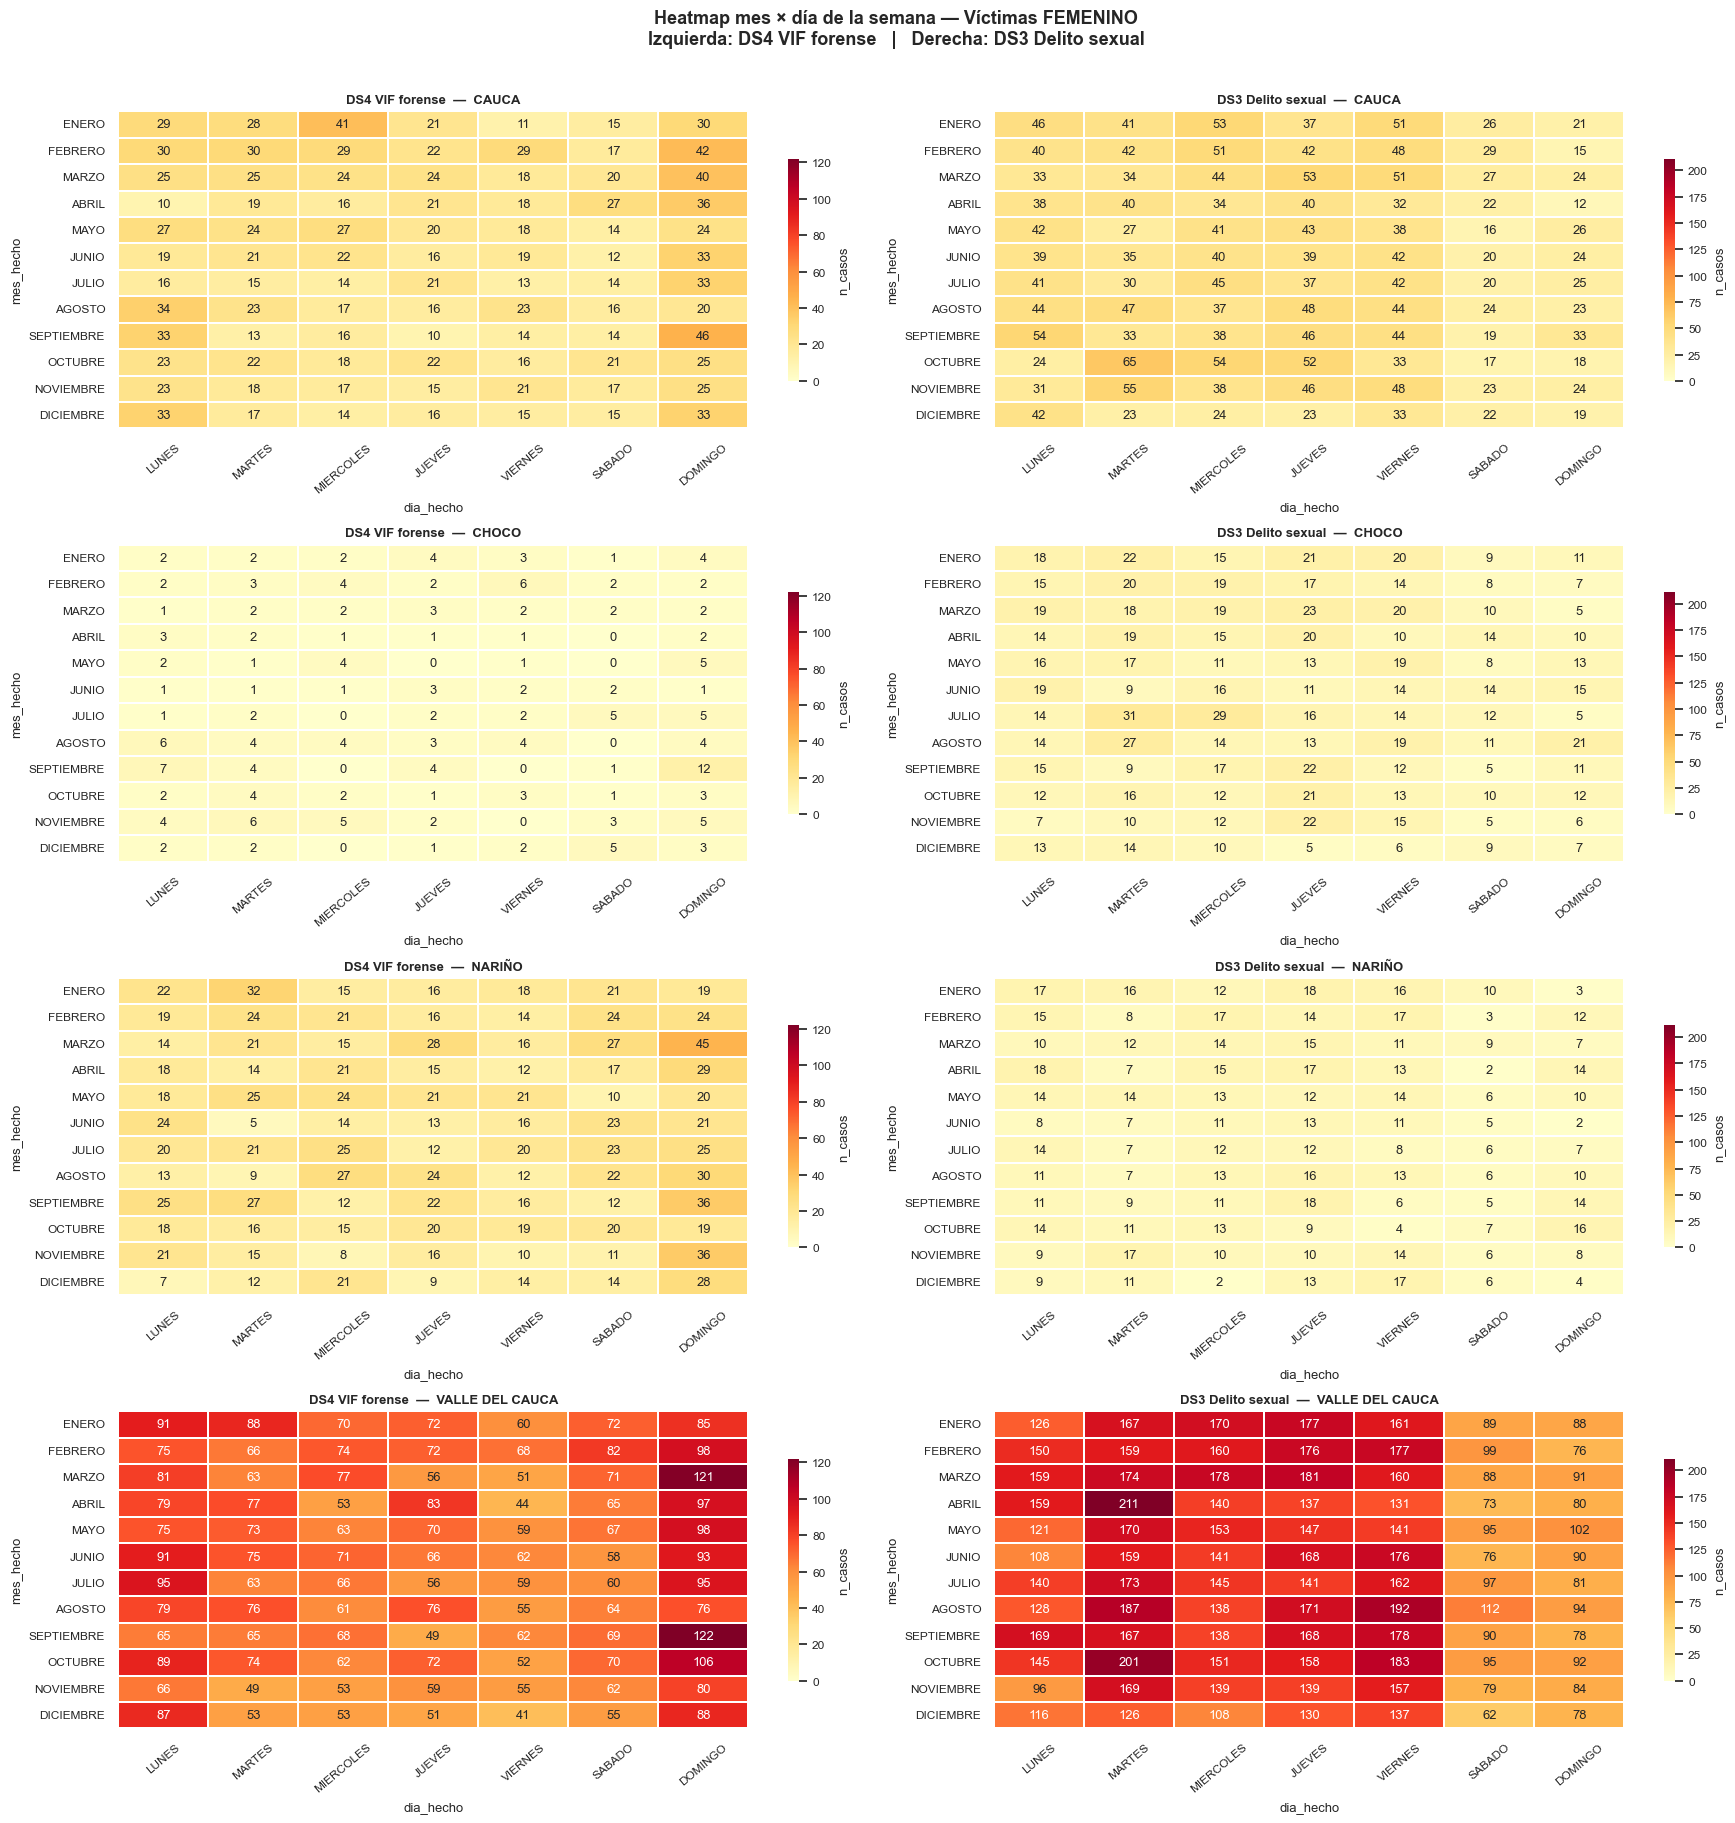

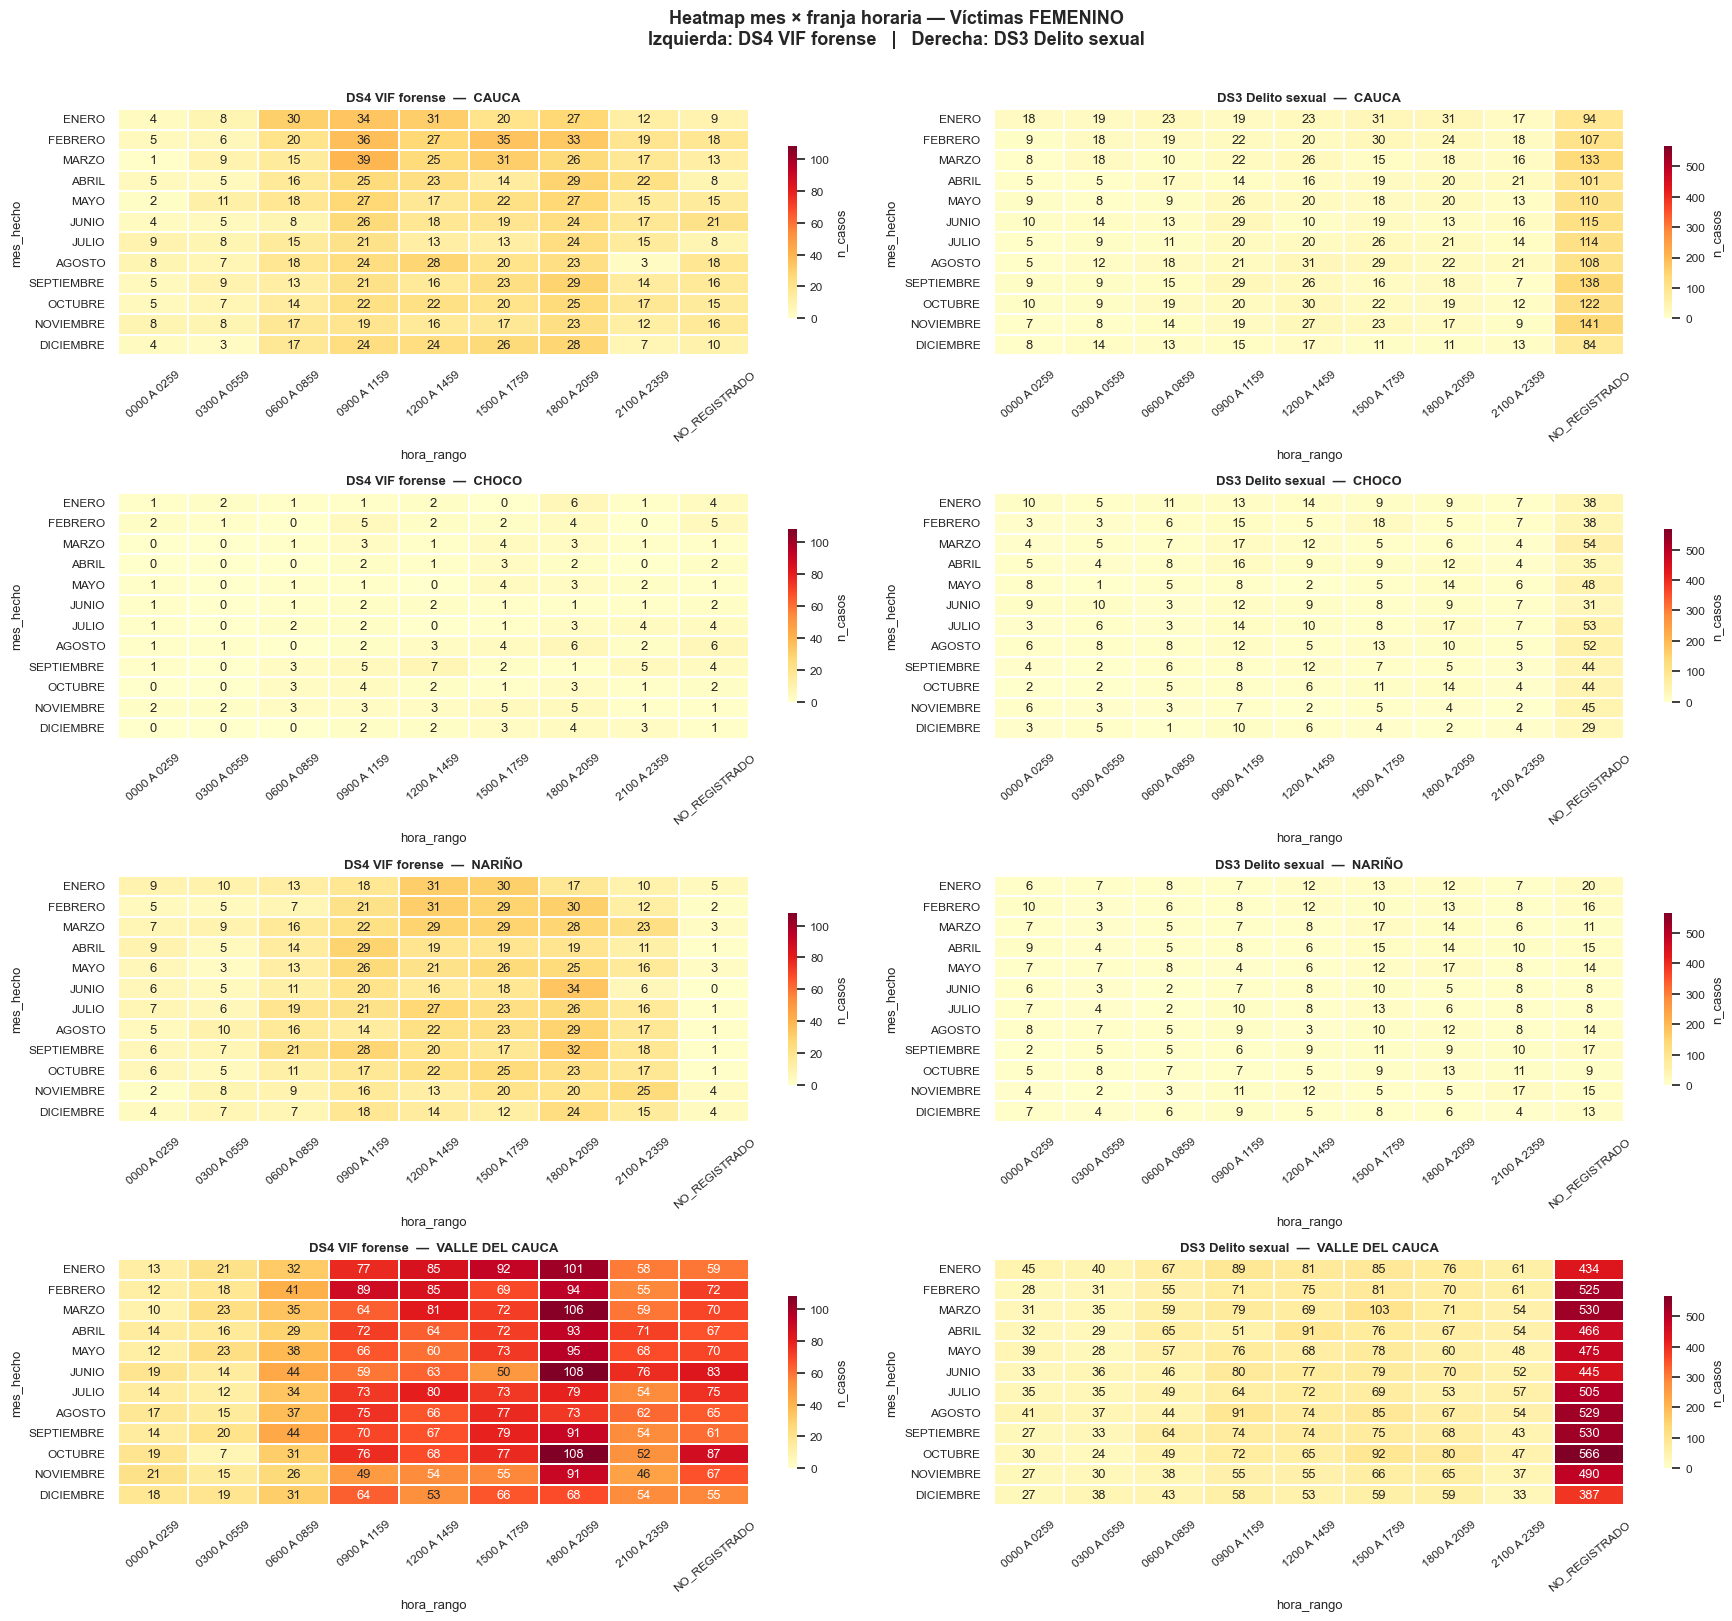

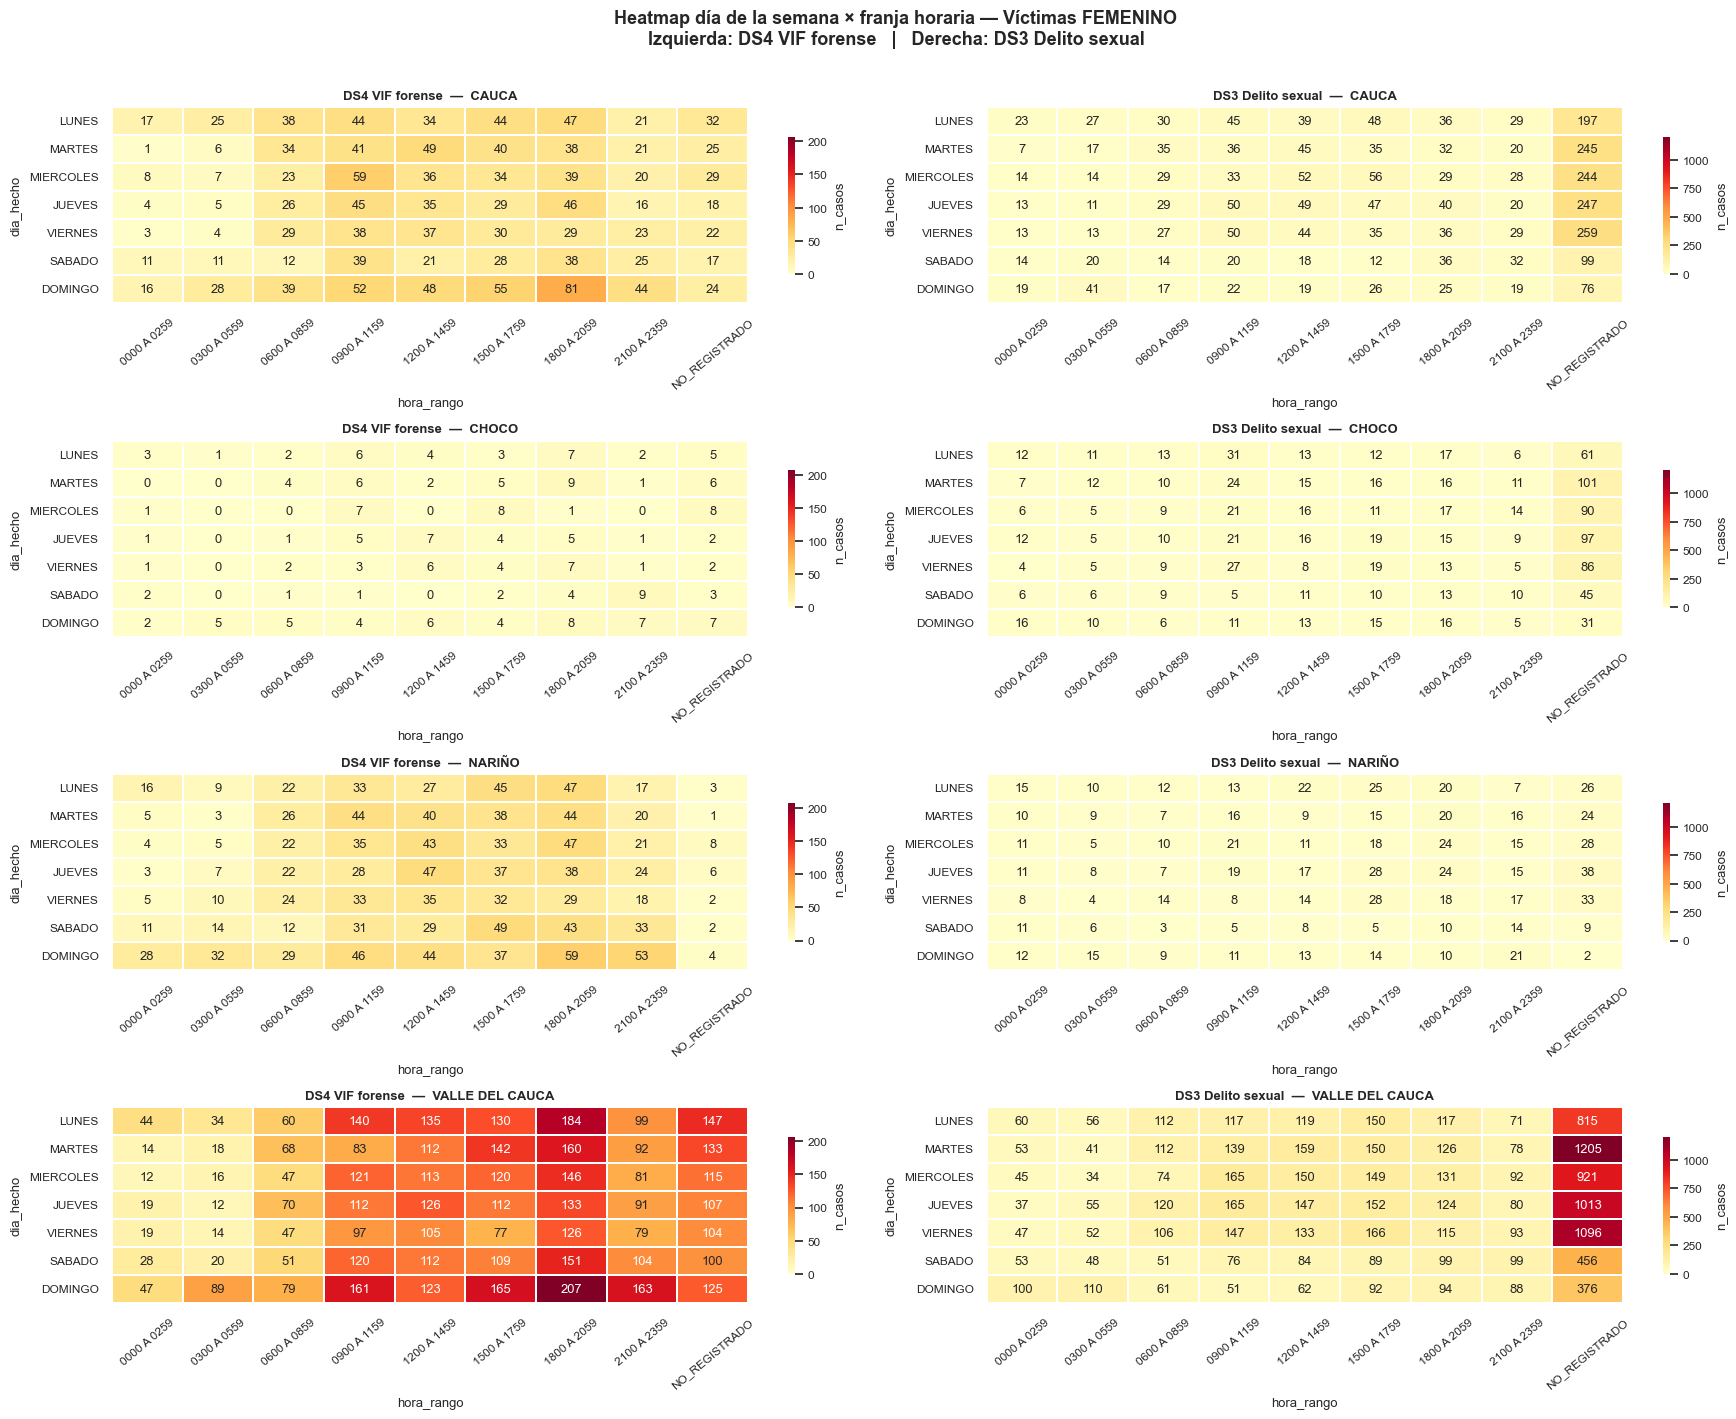

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "config").exists() else Path.cwd().parent

DS4_TEMP = PROJECT_ROOT / "data" / "agregados_forense"   / "ds4_temporalidad.parquet"
DS3_TEMP = PROJECT_ROOT / "data" / "agregados_seforense" / "ds3_temporalidad.parquet"

ds4 = pd.read_parquet(DS4_TEMP)
ds3 = pd.read_parquet(DS3_TEMP)

# ── Canonical orderings ──────────────────────────────────────────────────────
MESES = ["ENERO","FEBRERO","MARZO","ABRIL","MAYO","JUNIO",
         "JULIO","AGOSTO","SEPTIEMBRE","OCTUBRE","NOVIEMBRE","DICIEMBRE"]
DIAS  = ["LUNES","MARTES","MIERCOLES","JUEVES","VIERNES","SABADO","DOMINGO"]
DEPTS = sorted(ds4["departamento"].unique())

def apply_order(df, col, order):
    present = [v for v in order if v in df[col].values]
    return pd.Categorical(df[col], categories=present, ordered=True)

# ── Preview schema y valores únicos ─────────────────────────────────────────
for label, df in [("DS4 temporalidad", ds4), ("DS3 temporalidad", ds3)]:
    print(f"{label}  — shape: {df.shape}  cols: {df.columns.tolist()}")
    print(f"  departamento ({df['departamento'].nunique()}): {sorted(df['departamento'].unique())}")
    print(f"  mes_hecho    ({df['mes_hecho'].nunique()}): {sorted(df['mes_hecho'].unique())}")
    print(f"  dia_hecho    ({df['dia_hecho'].nunique()}): {sorted(df['dia_hecho'].unique())}")
    print(f"  hora_rango   ({df['hora_rango'].nunique()}): {sorted(df['hora_rango'].unique())}")
    print()

# ── Totales y picos por departamento ────────────────────────────────────────
print("=" * 70)
print("CASOS TOTALES POR DEPARTAMENTO  (víctimas FEMENINO)")
print("=" * 70)
for label, df in [("DS4 VIF forense", ds4), ("DS3 Delito sexual", ds3)]:
    dept_totals = df.groupby("departamento", observed=True)["n_casos"].sum().sort_values(ascending=False)
    print(f"\n{label}  (total: {dept_totals.sum():,})")
    for dept, n in dept_totals.items():
        pct = n / dept_totals.sum() * 100
        print(f"  {dept:<22}: {n:>6,}  ({pct:.1f}%)")

# ── Marginals por departamento ───────────────────────────────────────────────
print("\n" + "=" * 70)
print("PICOS TEMPORALES POR DEPARTAMENTO")
print("=" * 70)
for label, df in [("DS4 VIF forense", ds4), ("DS3 Delito sexual", ds3)]:
    print(f"\n{'─'*60}\n{label}")
    for dept in DEPTS:
        d = df[df["departamento"] == dept].copy()
        d["mes_hecho"] = apply_order(d, "mes_hecho", MESES)
        d["dia_hecho"] = apply_order(d, "dia_hecho", DIAS)
        total    = d["n_casos"].sum()
        por_mes  = d.groupby("mes_hecho",  observed=True)["n_casos"].sum().sort_index()
        por_dia  = d.groupby("dia_hecho",  observed=True)["n_casos"].sum().sort_index()
        por_hora = d.groupby("hora_rango", observed=True)["n_casos"].sum().sort_values(ascending=False)
        print(f"\n  {dept}  (total: {total:,})")
        print(f"    Mes pico : {por_mes.idxmax()}  ({por_mes.max():,})")
        print(f"    Día pico : {por_dia.idxmax()}  ({por_dia.max():,})")
        print(f"    Hora pico: {por_hora.idxmax()}  ({por_hora.max():,})")
        print(f"    Por mes  : {por_mes.to_dict()}")
        print(f"    Por día  : {por_dia.to_dict()}")
        print(f"    Por hora : {por_hora.sort_index().to_dict()}")

# ── Helpers para pivots ──────────────────────────────────────────────────────
def pivot_mes_dia(df, dept):
    d = df[df["departamento"] == dept].copy()
    d["mes_hecho"] = apply_order(d, "mes_hecho", MESES)
    d["dia_hecho"] = apply_order(d, "dia_hecho", DIAS)
    return d.groupby(["mes_hecho","dia_hecho"], observed=True)["n_casos"].sum().unstack("dia_hecho", fill_value=0)

def pivot_mes_hora(df, dept):
    d = df[df["departamento"] == dept].copy()
    d["mes_hecho"] = apply_order(d, "mes_hecho", MESES)
    hora_order = sorted(d["hora_rango"].unique())
    d["hora_rango"] = pd.Categorical(d["hora_rango"], categories=hora_order, ordered=True)
    return d.groupby(["mes_hecho","hora_rango"], observed=True)["n_casos"].sum().unstack("hora_rango", fill_value=0)

def pivot_dia_hora(df, dept):
    d = df[df["departamento"] == dept].copy()
    d["dia_hecho"] = apply_order(d, "dia_hecho", DIAS)
    hora_order = sorted(d["hora_rango"].unique())
    d["hora_rango"] = pd.Categorical(d["hora_rango"], categories=hora_order, ordered=True)
    return d.groupby(["dia_hecho","hora_rango"], observed=True)["n_casos"].sum().unstack("hora_rango", fill_value=0)

# ── Figura 1: mes × día por departamento (DS4 | DS3) ────────────────────────
sns.set_theme(style="white", font_scale=0.78)
cmap = "YlOrRd"

vmax_ds4_md = max(pivot_mes_dia(ds4, d).values.max() for d in DEPTS)
vmax_ds3_md = max(pivot_mes_dia(ds3, d).values.max() for d in DEPTS)

fig, axes = plt.subplots(len(DEPTS), 2, figsize=(18, 4.5 * len(DEPTS)))
fig.suptitle("Heatmap mes × día de la semana — Víctimas FEMENINO\n"
             "Izquierda: DS4 VIF forense   |   Derecha: DS3 Delito sexual",
             fontsize=13, fontweight="bold", y=1.01)

for row, dept in enumerate(DEPTS):
    for col, (df, ds_label, vmax) in enumerate([
        (ds4, "DS4 VIF forense",    vmax_ds4_md),
        (ds3, "DS3 Delito sexual",  vmax_ds3_md),
    ]):
        ax = axes[row, col]
        pivot = pivot_mes_dia(df, dept)
        sns.heatmap(
            pivot, ax=ax, cmap=cmap, vmin=0, vmax=vmax,
            annot=True, fmt=".0f",
            linewidths=0.3, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "n_casos"},
        )
        ax.set_title(f"{ds_label}  —  {dept}", fontweight="bold", pad=6)
        ax.set_xlabel("dia_hecho", labelpad=5)
        ax.set_ylabel("mes_hecho", labelpad=5)
        ax.tick_params(axis="x", rotation=40)
        ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()
print()

# ── Figura 2: mes × franja horaria por departamento (DS4 | DS3) ─────────────
vmax_ds4_mh = max(pivot_mes_hora(ds4, d).values.max() for d in DEPTS)
vmax_ds3_mh = max(pivot_mes_hora(ds3, d).values.max() for d in DEPTS)

fig2, axes2 = plt.subplots(len(DEPTS), 2, figsize=(18, 4 * len(DEPTS)))
fig2.suptitle("Heatmap mes × franja horaria — Víctimas FEMENINO\n"
              "Izquierda: DS4 VIF forense   |   Derecha: DS3 Delito sexual",
              fontsize=13, fontweight="bold", y=1.01)

for row, dept in enumerate(DEPTS):
    for col, (df, ds_label, vmax) in enumerate([
        (ds4, "DS4 VIF forense",   vmax_ds4_mh),
        (ds3, "DS3 Delito sexual", vmax_ds3_mh),
    ]):
        ax = axes2[row, col]
        pivot = pivot_mes_hora(df, dept)
        sns.heatmap(
            pivot, ax=ax, cmap=cmap, vmin=0, vmax=vmax,
            annot=True, fmt=".0f",
            linewidths=0.3, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "n_casos"},
        )
        ax.set_title(f"{ds_label}  —  {dept}", fontweight="bold", pad=6)
        ax.set_xlabel("hora_rango", labelpad=5)
        ax.set_ylabel("mes_hecho", labelpad=5)
        ax.tick_params(axis="x", rotation=40)
        ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()
print()

# ── Figura 3: día × franja horaria por departamento (DS4 | DS3) ─────────────
vmax_ds4_dh = max(pivot_dia_hora(ds4, d).values.max() for d in DEPTS)
vmax_ds3_dh = max(pivot_dia_hora(ds3, d).values.max() for d in DEPTS)

fig3, axes3 = plt.subplots(len(DEPTS), 2, figsize=(18, 3.5 * len(DEPTS)))
fig3.suptitle("Heatmap día de la semana × franja horaria — Víctimas FEMENINO\n"
              "Izquierda: DS4 VIF forense   |   Derecha: DS3 Delito sexual",
              fontsize=13, fontweight="bold", y=1.01)

for row, dept in enumerate(DEPTS):
    for col, (df, ds_label, vmax) in enumerate([
        (ds4, "DS4 VIF forense",   vmax_ds4_dh),
        (ds3, "DS3 Delito sexual", vmax_ds3_dh),
    ]):
        ax = axes3[row, col]
        pivot = pivot_dia_hora(df, dept)
        sns.heatmap(
            pivot, ax=ax, cmap=cmap, vmin=0, vmax=vmax,
            annot=True, fmt=".0f",
            linewidths=0.3, linecolor="white",
            cbar_kws={"shrink": 0.7, "label": "n_casos"},
        )
        ax.set_title(f"{ds_label}  —  {dept}", fontweight="bold", pad=6)
        ax.set_xlabel("hora_rango", labelpad=5)
        ax.set_ylabel("dia_hecho", labelpad=5)
        ax.tick_params(axis="x", rotation=40)
        ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()
